# Continual Gait Identification — Unified Security Evaluation

**Thesis:** Code Division Modulation Layers Against Forgetting and Inference in Continual Gait Identification

---

## Overview

This notebook provides a **structured, end-to-end evaluation** of six continual learning models under three privacy attacks. The central research question is:

> *Which model achieves the best trade-off between continual learning accuracy and resistance to privacy attacks?*

### Models evaluated

| # | Model | Description | Anti-forgetting | Privacy mechanism |
|---|---|---|---|---|
| 1 | **Std 0%** | Baseline sequential fine-tuning | None | None |
| 2 | **Std 15%** | Fine-tuning with 15% raw replay | Experience replay | None |
| 3 | **CDML** | Code Division Modulation Layers | Sequence modulation | Per-task key |
| 4 | **CDML+KD** | CDML + focal knowledge distillation | Distillation + key | Per-task key |
| 5 | **WGR-CDML** | CDML + wavelet generative replay | Synthetic replay + key | Per-task key + no raw data |
| 6 | **LiDER** | CDML + Lipschitz-driven replay | Spectral regularisation + key | Per-task key |

### Attacks evaluated

| # | Attack | Type | Goal |
|---|---|---|---|
| A | **Identity Inference Attack (IIA)** | Black-box, score-based | Was this specific person enrolled? |
| B | **Feature Space Inference** | White-box, geometry-based | Can embeddings be used to identify users? |
| C | **Backdoor / Trojan Attack** | Poisoning | Does a trigger reliably authenticate an attacker? |

### Threat model for CDML models

All CDML-based models are evaluated under two attacker levels:
- **No-seed** (realistic): attacker zeros out the modulation sequence — the only information available from black-box access
- **Oracle** (upper bound): attacker knows the correct seed — measures the maximum possible leakage

---

## 0. Imports

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import (
    DataLoader, TensorDataset, random_split, ConcatDataset, Subset
)
from sklearn.metrics import roc_curve, auc as sk_auc
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')

try:
    import pywt
    PYWT_AVAILABLE = True
    print('PyWavelets available — using DWT decomposition')
except ImportError:
    PYWT_AVAILABLE = False
    print('PyWavelets not found — using FFT fallback for WGR')

plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}  |  PyTorch: {torch.__version__}')

PyWavelets available — using DWT decomposition
Device: mps  |  PyTorch: 2.8.0


## 1. Configuration

All hyperparameters are defined here. Set `EPOCHS = 400` for paper-accurate results.

In [9]:
DATA_DIR = "../Data/UCI HAR Dataset"

N_CHANNELS      = 6
WINDOW_SIZE     = 128
VAL_SPLIT       = 0.15
RANDOM_SEED     = 27
BATCH_SIZE      = 64
EMBED_DIM       = 128
N_CLASSES_TOTAL = 30
CDML_SEED_BASE  = 1000

EPOCHS   = 100   # 100 = fast iteration | 400 = paper-accurate
LR_INIT  = 1e-3
LR_DECAY = 0.95

TASK_SPLITS = {
    'Task 1': (1,   10),
    'Task 2': (11,  17),
    'Task 3': (18,  24),
    'Task 4': (25,  30),
}

# ── Model hyperparameters ─────────────────────────────────────────────────────
STD_REPLAY_FRAC  = 0.15   # Std 15% model

# CDML+KD (focal distillation)
KD_LAMBDA        = 0.001
KD_ALPHA         = 0.0    # focal: 0 = only penalise correct-sample divergence
KD_BETA          = 1.0
KD_MEMORY_FRAC   = 0.20

# WGR-CDML (Wavelet Generative Replay)
WGR_WAVELET      = 'db4'
WGR_LEVEL        = 3
WGR_N_SYNTH      = 30
WGR_JITTER_STD   = 0.05

# LiDER (Lipschitz-Driven Experience Replay)
LIDER_REPLAY_FRAC = 0.10
LIDER_WEIGHT      = 0.01
LIDER_KAPPA       = 2.0

# ── Attack A — IIA ────────────────────────────────────────────────────────────
IIA_N_QUERIES    = 20
IIA_AGGREGATION  = 'mean'

# ── Attack B — Feature Space Inference ───────────────────────────────────────
KNN_K            = 5

# ── Attack C — Backdoor ───────────────────────────────────────────────────────
BACKDOOR_TARGET_IDX  = 27    # Task 4 subject (never forgotten)
BACKDOOR_POISON_FRAC = 0.15
BACKDOOR_TRIGGER_AMP = 0.5
BACKDOOR_TRIGGER_FREQ = 8
BACKDOOR_TRIGGER_CH  = 2     # acc_z channel

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print('Configuration set.')

Configuration set.


## 2. Data loading

In [10]:
def load_split_uci(data_dir, prefix):
    """Loads Inertial Signals, Activity Labels, and Subject IDs for UCI HAR"""
    axes = ['total_acc_x', 'total_acc_y', 'total_acc_z',
            'body_gyro_x', 'body_gyro_y', 'body_gyro_z']
    signals = [np.loadtxt(f'{data_dir}/{prefix}/Inertial Signals/{a}_{prefix}.txt') for a in axes]
    X = np.stack(signals, axis=1).astype(np.float32)   # (N, 6, 128)
    activities = np.loadtxt(f'{data_dir}/{prefix}/y_{prefix}.txt',       dtype=int)
    subjects   = np.loadtxt(f'{data_dir}/{prefix}/subject_{prefix}.txt', dtype=int)
    return X, activities, subjects

# --- 1. Load both UCI HAR splits and immediately merge them ---
# UCI HAR splits by *subject* (21 train / 9 test), which means several subjects
# appear in only one partition.  For gait identification we need every subject
# to have both training and test windows, so we pool everything first.
X_tr_raw, act_tr_raw, subj_tr_raw = load_split_uci(DATA_DIR, 'train')
X_te_raw, act_te_raw, subj_te_raw = load_split_uci(DATA_DIR, 'test')

X_all    = np.concatenate([X_tr_raw,    X_te_raw],    axis=0)   # (N_total, 6, 128)
act_all  = np.concatenate([act_tr_raw,  act_te_raw],  axis=0)
subj_all = np.concatenate([subj_tr_raw, subj_te_raw], axis=0)
print(f'Merged pool — total windows: {len(X_all)}')

# --- 2. Filter for WALKING only (Activity ID == 1) ---
walk_mask = (act_all == 1)
X_walk    = X_all[walk_mask]
y_walk    = subj_all[walk_mask]   # original subject IDs  (1–30)
print(f'Walking windows: {X_walk.shape}')

# --- 3. Per-subject 80 / 20 window split ---
# Splitting windows within each subject guarantees that every subject
# contributes samples to both train and test — a requirement for
# continual gait identification and membership-inference evaluation.
rng_np         = np.random.default_rng(RANDOM_SEED)
tr_idx, te_idx = [], []
for subj in np.unique(y_walk):
    idx = np.where(y_walk == subj)[0]
    rng_np.shuffle(idx)
    cut = max(1, int(len(idx) * (1.0 - VAL_SPLIT)))   # ~85 % train
    tr_idx.extend(idx[:cut].tolist())
    te_idx.extend(idx[cut:].tolist())

tr_idx = np.array(tr_idx)
te_idx = np.array(te_idx)

X_train, y_train_subj = X_walk[tr_idx], y_walk[tr_idx]
X_test,  y_test_subj  = X_walk[te_idx], y_walk[te_idx]

# --- 4. Normalise — fit statistics on training windows only ---
ch_mean = X_train.mean(axis=(0, 2), keepdims=True)   # (1, 6, 1)
ch_std  = X_train.std( axis=(0, 2), keepdims=True) + 1e-8
X_train_norm = (X_train - ch_mean) / ch_std
X_test_norm  = (X_test  - ch_mean) / ch_std

# --- 5. Build 0-indexed PyTorch labels ---
unique_labels = np.sort(np.unique(y_walk))            # all 30 subjects
label_to_idx  = {lbl: idx for idx, lbl in enumerate(unique_labels)}
y_train_idx   = np.array([label_to_idx[l] for l in y_train_subj])
y_test_idx    = np.array([label_to_idx[l] for l in y_test_subj])

# --- 6. Build per-task datasets ---
def make_task_datasets(X_tr, y_tr_orig, y_tr_idx, X_te, y_te_orig, y_te_idx,
                       task_splits, val_split, seed):
    rng = torch.Generator().manual_seed(seed)
    task_data = {}
    for task_name, (lo, hi) in task_splits.items():
        mask_tr  = (y_tr_orig >= lo) & (y_tr_orig <= hi)
        X_t = torch.tensor(X_tr[mask_tr])
        y_t = torch.tensor(y_tr_idx[mask_tr], dtype=torch.long)
        full  = TensorDataset(X_t, y_t)
        n_val = max(1, int(len(full) * val_split))
        train_ds, val_ds = random_split(full, [len(full) - n_val, n_val], generator=rng)
        mask_te = (y_te_orig >= lo) & (y_te_orig <= hi)
        test_ds = TensorDataset(
            torch.tensor(X_te[mask_te]),
            torch.tensor(y_te_idx[mask_te], dtype=torch.long))
        task_data[task_name] = {'train': train_ds, 'val': val_ds, 'test': test_ds}
        print(f'{task_name}: {len(train_ds):>4} train | {n_val:>3} val | {len(test_ds):>4} test')
    return task_data

print("\nBuilding Continual Learning Tasks (Walking Only)...")
task_data  = make_task_datasets(
    X_train_norm, y_train_subj, y_train_idx,
    X_test_norm,  y_test_subj,  y_test_idx,
    TASK_SPLITS, VAL_SPLIT, RANDOM_SEED)

task_names = list(TASK_SPLITS.keys())
n_tasks    = len(task_names)
print(f'\nTrain pool : {X_train.shape}')
print(f'Test  pool : {X_test.shape}')

Merged pool — total windows: 10299
Walking windows: (1722, 6, 128)

Building Continual Learning Tasks (Walking Only)...
Task 1:  427 train |  75 val |   93 test
Task 2:  280 train |  49 val |   62 test
Task 3:  269 train |  47 val |   58 test
Task 4:  260 train |  45 val |   57 test

Train pool : (1452, 6, 128)
Test  pool : (270, 6, 128)


## 3. Model definitions

In [11]:
# ── Shared backbone ───────────────────────────────────────────────────────────
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, pool=2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=kernel_size//2),
            nn.ReLU(), nn.MaxPool1d(pool),
        )
    def forward(self, x): return self.block(x)

class GaitCNN(nn.Module):
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128):
        super().__init__()
        self.embed_dim = embed_dim
        self.feature_extractor = nn.Sequential(
            ConvBlock(n_channels, 32), ConvBlock(32, 64),
            ConvBlock(64, 128),        ConvBlock(128, 128), nn.Flatten(),
        )
        flat = self.feature_extractor(torch.zeros(1, n_channels, WINDOW_SIZE)).shape[1]
        self.embedding  = nn.Linear(flat, embed_dim)
        self.classifier = nn.Linear(embed_dim, n_classes)
    def embed(self, x): return self.embedding(self.feature_extractor(x))
    def forward(self, x): return self.classifier(self.embed(x))

# ── CDML layer and model ──────────────────────────────────────────────────────
def generate_cdml_sequence(embed_dim, seed):
    rng = np.random.default_rng(seed)
    return torch.tensor(np.where(rng.random(embed_dim) >= 0.5, 1.0, -1.0).astype(np.float32))

class CDMLLayer(nn.Module):
    def __init__(self, embed_dim, seed):
        super().__init__()
        self.register_buffer('sequence', generate_cdml_sequence(embed_dim, seed))
    def forward(self, h): return h * self.sequence

class GaitCNN_CDML(nn.Module):
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128, seed=CDML_SEED_BASE):
        super().__init__()
        self.embed_dim = embed_dim
        self.backbone  = GaitCNN(n_channels, n_classes, embed_dim)
        self.cdml      = CDMLLayer(embed_dim, seed)
        self.seeds     = {}
    def embed_raw(self, x):        return self.backbone.embed(x)
    def embed_modulated(self, x):  return self.cdml(self.backbone.embed(x))
    def forward(self, x):          return self.backbone.classifier(self.cdml(self.backbone.embed(x)))
    def set_task_sequence(self, task_name, seed):
        self.seeds[task_name] = seed
        self.cdml.sequence = generate_cdml_sequence(
            self.embed_dim, seed).to(next(self.parameters()).device)
    def zero_sequence(self):
        """Attacker without seed: zeroes all embeddings."""
        self.cdml.sequence = torch.zeros(
            self.embed_dim, device=next(self.parameters()).device)

# ── Shared utilities ──────────────────────────────────────────────────────────
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    c, t = 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        c += (model(X_b).argmax(1) == y_b).sum().item()
        t += len(y_b)
    return c / t

def make_replay_subset(dataset, frac, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    n   = len(dataset)
    k   = max(1, int(n * frac))
    idx = rng.choice(n, k, replace=False).tolist()
    Xs, ys = zip(*[dataset[i] for i in idx])
    return TensorDataset(torch.stack(Xs), torch.stack(ys))

print(f'GaitCNN params: {sum(p.numel() for p in GaitCNN(N_CHANNELS,N_CLASSES_TOTAL,EMBED_DIM).parameters()):,}')
print('Model classes defined.')

GaitCNN params: 215,870
Model classes defined.


## 4. WGR and LiDER-specific components

In [12]:
# ── Wavelet utilities (WGR-CDML) ──────────────────────────────────────────────
def _fft_approximate(X_np, low_frac=0.125):
    F   = np.fft.rfft(X_np, axis=-1)
    cut = max(1, int(F.shape[-1] * low_frac))
    F_l = F.copy(); F_l[..., cut:] = 0
    F_h = F.copy(); F_h[..., :cut] = 0
    return np.fft.irfft(F_l, n=X_np.shape[-1], axis=-1), \
           np.fft.irfft(F_h, n=X_np.shape[-1], axis=-1)

class WaveletReplayBuffer:
    """Stores per-class DWT statistics, generates synthetic gait windows on demand."""
    def __init__(self, wavelet=WGR_WAVELET, level=WGR_LEVEL,
                 n_synth=WGR_N_SYNTH, jitter_std=WGR_JITTER_STD, seed=RANDOM_SEED):
        self.wavelet = wavelet; self.level = level
        self.n_synth = n_synth; self.jitter = jitter_std
        self.rng = np.random.default_rng(seed)
        self._tasks = []

    def _to_numpy(self, ds):
        X = torch.stack([ds[i][0] for i in range(len(ds))]).numpy()
        y = torch.stack([ds[i][1] for i in range(len(ds))]).numpy()
        return X, y

    def add_task(self, train_ds, task_name):
        X_np, y_np = self._to_numpy(train_ds)
        N, C, T    = X_np.shape
        classes    = np.unique(y_np)
        if PYWT_AVAILABLE:
            class_stats, detail_stats = {}, []
            all_c = [[pywt.wavedec(X_np[n, c, :], self.wavelet, level=self.level)
                      for c in range(C)] for n in range(N)]
            for cls in classes:
                mask  = (y_np == cls)
                cA_st = np.array([[all_c[i][c][0] for c in range(C)]
                                   for i in range(N) if mask[i]])
                flat  = cA_st.reshape(cA_st.shape[0], -1)
                class_stats[int(cls)] = {'mu': flat.mean(0), 'sigma': flat.std(0)+1e-6}
            for lv in range(1, self.level+1):
                cD = np.array([[all_c[i][c][lv] for c in range(C)] for i in range(N)])
                detail_stats.append({'mu': cD.mean(0), 'sigma': cD.std(0)+1e-6})
            coeff_lens = [len(a) for a in all_c[0][0]]
        else:
            X_low, X_high = _fft_approximate(X_np)
            class_stats = {int(cls): {'mu': X_low[y_np==cls].reshape(sum(y_np==cls),-1).mean(0),
                                       'sigma': X_low[y_np==cls].reshape(sum(y_np==cls),-1).std(0)+1e-6}
                           for cls in classes}
            detail_stats = [{'mu': X_high.mean(0), 'sigma': X_high.std(0)+1e-6}]
            coeff_lens = None
        self._tasks.append({'task_name': task_name, 'class_stats': class_stats,
                             'detail_stats': detail_stats, 'coeff_lens': coeff_lens,
                             'n_channels': C, 'window_size': T,
                             'classes': list(classes.astype(int))})
        print(f'  WGR buffer: stored statistics for {task_name} ({len(classes)} classes)')

    def synthesize_task(self, task_idx):
        task = self._tasks[task_idx]
        C, T = task['n_channels'], task['window_size']
        X_list, y_list = [], []
        if PYWT_AVAILABLE:
            for cls, stats in task['class_stats'].items():
                for _ in range(self.n_synth):
                    cA_flat = self.rng.normal(stats['mu'], stats['sigma'])
                    cA      = cA_flat.reshape(C, -1)
                    window  = np.zeros((C, T), dtype=np.float32)
                    for c in range(C):
                        coeffs_c = [cA[c].astype(float)]
                        for lv_s in task['detail_stats']:
                            coeffs_c.append(self.rng.normal(lv_s['mu'][c], lv_s['sigma'][c]).astype(float))
                        recon = pywt.waverec(coeffs_c, self.wavelet)
                        window[c] = recon[:T] if len(recon) >= T else np.pad(recon.astype(np.float32), (0, T-len(recon)))
                    window += self.rng.normal(0, self.jitter, window.shape).astype(np.float32)
                    X_list.append(window); y_list.append(cls)
        else:
            for cls, stats in task['class_stats'].items():
                det = task['detail_stats'][0]
                for _ in range(self.n_synth):
                    xl = self.rng.normal(stats['mu'], stats['sigma']).reshape(C, T//4)
                    xl = np.repeat(xl, 4, axis=-1)[:, :T]
                    xh = self.rng.normal(det['mu'], det['sigma']).reshape(C, -1)[:, :T]
                    if xh.shape[-1] < T: xh = np.pad(xh, ((0,0),(0,T-xh.shape[-1])))
                    window = (xl + xh).astype(np.float32)
                    window += self.rng.normal(0, self.jitter, window.shape).astype(np.float32)
                    X_list.append(window); y_list.append(cls)
        return TensorDataset(torch.tensor(np.stack(X_list)),
                             torch.tensor(y_list, dtype=torch.long))

    def get_replay_dataset(self):
        if not self._tasks: return None
        parts = [self.synthesize_task(i) for i in range(len(self._tasks))]
        return ConcatDataset(parts)

# ── LiDER spectral norm utility ───────────────────────────────────────────────
def spectral_norm_approx(W, n_iter=3):
    W2d = W.view(W.shape[0], -1)
    if min(W2d.shape) == 0: return torch.tensor(0.0, device=W.device)
    u = F.normalize(torch.randn(W2d.shape[0], 1, device=W.device), dim=0)
    v = F.normalize(torch.randn(W2d.shape[1], 1, device=W.device), dim=0)
    for _ in range(n_iter):
        v = F.normalize(W2d.t() @ u, dim=0)
        u = F.normalize(W2d @ v,     dim=0)
    return (u.t() @ W2d @ v).squeeze().abs()

def lider_penalty(model, kappa=LIDER_KAPPA):
    """L_LiDER = Σ_l max(0, σ(W_l) − κ)²   (Bonicelli et al. NeurIPS 2022)"""
    total    = torch.tensor(0.0, device=next(model.parameters()).device)
    backbone = model.backbone if hasattr(model, 'backbone') else model
    for m in backbone.modules():
        if isinstance(m, (nn.Conv1d, nn.Linear)):
            total = total + F.relu(spectral_norm_approx(m.weight) - kappa) ** 2
    return total

# ── KD distillation loss (CDML+KD) ────────────────────────────────────────────
def focal_distill_loss(logits_new, logits_old, y_true, alpha, beta):
    """L_KD = (α + β·I[ŷ_old=y]) · ‖f_new−f_old‖²   (Angioni et al. 2025)"""
    l2      = ((logits_new - logits_old)**2).sum(dim=1)
    correct = (logits_old.argmax(1) == y_true).float()
    return ((alpha + beta * correct) * l2).mean()

print('All model components defined.')

All model components defined.


## 5. Training — all six models

Each model is trained sequentially on Tasks 1→4. After each task a snapshot is saved.

In [13]:
def _run_epoch(model, loader, optimizer, criterion, device,
               is_cdml=False, task_name=None, seed_k=None,
               kd_old=None, buf_iter=None, buf_loader=None,
               lider_w=0.0, kappa=2.0):
    model.train()
    if is_cdml and task_name: model.set_task_sequence(task_name, seed_k)
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b)
        # KD term
        if kd_old is not None and buf_iter is not None:
            try:    Xp, yp = next(buf_iter)
            except: buf_iter = iter(buf_loader); Xp, yp = next(buf_iter)
            Xp, yp = Xp.to(device), yp.to(device)
            with torch.no_grad(): lo = kd_old(Xp)
            loss = loss + KD_LAMBDA * focal_distill_loss(model(Xp), lo, yp, KD_ALPHA, KD_BETA)
        # LiDER term
        if lider_w > 0:
            loss = loss + lider_w * lider_penalty(model, kappa)
        loss.backward()
        optimizer.step()
    return buf_iter


def _eval_all_tasks(model, task_data, task_names, step_idx, acc_mat, device, is_cdml):
    for ei, et in enumerate(task_names[:step_idx+1]):
        if is_cdml: model.set_task_sequence(et, model.seeds[et])
        tl  = DataLoader(task_data[et]['test'], batch_size=256)
        acc_mat[step_idx, ei] = evaluate(model, tl, device)


def train_std(task_data, task_names, device, epochs, lr_init, lr_decay,
               batch_size, replay_frac=0.0, label='Std', verbose_every=25):
    """Std or Std+replay training."""
    torch.manual_seed(RANDOM_SEED)
    model      = GaitCNN(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    criterion  = nn.CrossEntropyLoss()
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    replay_buf = []

    for step_idx, task_name in enumerate(task_names):
        print(f'[{label}] Step {step_idx+1}: {task_name}')
        datasets = [task_data[task_name]['train']] + replay_buf
        loader   = DataLoader(ConcatDataset(datasets), batch_size=batch_size, shuffle=True)
        optimizer  = optim.Adam(model.parameters(), lr=lr_init)
        scheduler  = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        for epoch in range(1, epochs+1):
            _run_epoch(model, loader, optimizer, criterion, device)
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                vl = DataLoader(task_data[task_name]['val'], batch_size=batch_size)
                print(f'  Epoch {epoch:>3}/{epochs}  val={evaluate(model, vl, device):.3f}')
        _eval_all_tasks(model, task_data, task_names, step_idx, acc_matrix, device, False)
        row = '  '.join([f'T{j+1}:{acc_matrix[step_idx,j]*100:.1f}%' for j in range(step_idx+1)])
        print(f'  → {row}')
        if replay_frac > 0:
            replay_buf.append(make_replay_subset(task_data[task_name]['train'], replay_frac))
    return model, acc_matrix


def train_cdml(task_data, task_names, device, epochs, lr_init, lr_decay,
                batch_size, label='CDML', verbose_every=25):
    """Plain CDML — no replay."""
    torch.manual_seed(RANDOM_SEED)
    model      = GaitCNN_CDML(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    criterion  = nn.CrossEntropyLoss()
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)

    for step_idx, task_name in enumerate(task_names):
        seed_k = CDML_SEED_BASE + step_idx
        model.set_task_sequence(task_name, seed_k)
        print(f'[{label}] Step {step_idx+1}: {task_name}  (seed={seed_k})')
        loader    = DataLoader(task_data[task_name]['train'], batch_size=batch_size, shuffle=True)
        optimizer = optim.Adam(model.parameters(), lr=lr_init)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        for epoch in range(1, epochs+1):
            _run_epoch(model, loader, optimizer, criterion, device,
                       is_cdml=True, task_name=task_name, seed_k=seed_k)
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                model.set_task_sequence(task_name, seed_k)
                vl = DataLoader(task_data[task_name]['val'], batch_size=batch_size)
                print(f'  Epoch {epoch:>3}/{epochs}  val={evaluate(model, vl, device):.3f}')
        _eval_all_tasks(model, task_data, task_names, step_idx, acc_matrix, device, True)
        model.set_task_sequence(task_name, seed_k)
        row = '  '.join([f'T{j+1}:{acc_matrix[step_idx,j]*100:.1f}%' for j in range(step_idx+1)])
        print(f'  → {row}')
    return model, acc_matrix


def train_cdml_kd(task_data, task_names, device, epochs, lr_init, lr_decay,
                   batch_size, label='CDML+KD', verbose_every=25):
    """CDML + focal knowledge distillation (Phase 5)."""
    torch.manual_seed(RANDOM_SEED)
    model      = GaitCNN_CDML(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    criterion  = nn.CrossEntropyLoss()
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    old_model  = None
    mem_buf    = []

    for step_idx, task_name in enumerate(task_names):
        seed_k = CDML_SEED_BASE + step_idx
        model.set_task_sequence(task_name, seed_k)
        print(f'[{label}] Step {step_idx+1}: {task_name}')
        loader     = DataLoader(task_data[task_name]['train'], batch_size=batch_size, shuffle=True)
        buf_loader = DataLoader(ConcatDataset(mem_buf), batch_size=batch_size,
                                shuffle=True) if mem_buf else None
        optimizer  = optim.Adam(model.parameters(), lr=lr_init)
        scheduler  = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        for epoch in range(1, epochs+1):
            buf_iter = iter(buf_loader) if buf_loader else None
            buf_iter = _run_epoch(model, loader, optimizer, criterion, device,
                                  is_cdml=True, task_name=task_name, seed_k=seed_k,
                                  kd_old=old_model, buf_iter=buf_iter, buf_loader=buf_loader)
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                model.set_task_sequence(task_name, seed_k)
                vl = DataLoader(task_data[task_name]['val'], batch_size=batch_size)
                print(f'  Epoch {epoch:>3}/{epochs}  val={evaluate(model, vl, device):.3f}')
        old_model = deepcopy(model); old_model.eval()
        for p in old_model.parameters(): p.requires_grad_(False)
        mem_buf.append(make_replay_subset(task_data[task_name]['train'], KD_MEMORY_FRAC,
                                          seed=RANDOM_SEED+step_idx))
        _eval_all_tasks(model, task_data, task_names, step_idx, acc_matrix, device, True)
        model.set_task_sequence(task_name, seed_k)
        row = '  '.join([f'T{j+1}:{acc_matrix[step_idx,j]*100:.1f}%' for j in range(step_idx+1)])
        print(f'  → {row}')
    return model, acc_matrix


def train_wgr_cdml(task_data, task_names, device, epochs, lr_init, lr_decay,
                    batch_size, label='WGR-CDML', verbose_every=25):
    """WGR-CDML: CDML + wavelet generative replay (no raw data stored)."""
    torch.manual_seed(RANDOM_SEED)
    model      = GaitCNN_CDML(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    criterion  = nn.CrossEntropyLoss()
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    wgr_buf    = WaveletReplayBuffer()

    for step_idx, task_name in enumerate(task_names):
        seed_k = CDML_SEED_BASE + step_idx
        model.set_task_sequence(task_name, seed_k)
        print(f'[{label}] Step {step_idx+1}: {task_name}')
        datasets = [task_data[task_name]['train']]
        if step_idx > 0:
            synth = wgr_buf.get_replay_dataset()
            if synth is not None:
                datasets.append(synth)
                print(f'  + {len(synth)} synthetic replay samples')
        loader    = DataLoader(ConcatDataset(datasets), batch_size=batch_size, shuffle=True)
        optimizer = optim.Adam(model.parameters(), lr=lr_init)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        for epoch in range(1, epochs+1):
            model.set_task_sequence(task_name, seed_k)
            _run_epoch(model, loader, optimizer, criterion, device,
                       is_cdml=True, task_name=task_name, seed_k=seed_k)
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                model.set_task_sequence(task_name, seed_k)
                vl = DataLoader(task_data[task_name]['val'], batch_size=batch_size)
                print(f'  Epoch {epoch:>3}/{epochs}  val={evaluate(model, vl, device):.3f}')
        _eval_all_tasks(model, task_data, task_names, step_idx, acc_matrix, device, True)
        model.set_task_sequence(task_name, seed_k)
        row = '  '.join([f'T{j+1}:{acc_matrix[step_idx,j]*100:.1f}%' for j in range(step_idx+1)])
        print(f'  → {row}')
        wgr_buf.add_task(task_data[task_name]['train'], task_name)
    return model, acc_matrix


def train_lider(task_data, task_names, device, epochs, lr_init, lr_decay,
                 batch_size, label='LiDER', verbose_every=25):
    """LiDER: CDML + 10% experience replay + Lipschitz spectral penalty."""
    torch.manual_seed(RANDOM_SEED)
    model      = GaitCNN_CDML(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    criterion  = nn.CrossEntropyLoss()
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    replay_buf = []

    for step_idx, task_name in enumerate(task_names):
        seed_k = CDML_SEED_BASE + step_idx
        model.set_task_sequence(task_name, seed_k)
        print(f'[{label}] Step {step_idx+1}: {task_name}')
        datasets = [task_data[task_name]['train']] + replay_buf
        loader   = DataLoader(ConcatDataset(datasets), batch_size=batch_size, shuffle=True)
        optimizer = optim.Adam(model.parameters(), lr=lr_init)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        lider_w   = LIDER_WEIGHT if step_idx > 0 else 0.0
        for epoch in range(1, epochs+1):
            model.set_task_sequence(task_name, seed_k)
            _run_epoch(model, loader, optimizer, criterion, device,
                       is_cdml=True, task_name=task_name, seed_k=seed_k,
                       lider_w=lider_w, kappa=LIDER_KAPPA)
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                model.set_task_sequence(task_name, seed_k)
                vl = DataLoader(task_data[task_name]['val'], batch_size=batch_size)
                print(f'  Epoch {epoch:>3}/{epochs}  val={evaluate(model, vl, device):.3f}')
        _eval_all_tasks(model, task_data, task_names, step_idx, acc_matrix, device, True)
        model.set_task_sequence(task_name, seed_k)
        row = '  '.join([f'T{j+1}:{acc_matrix[step_idx,j]*100:.1f}%' for j in range(step_idx+1)])
        print(f'  → {row}')
        replay_buf.append(make_replay_subset(task_data[task_name]['train'], LIDER_REPLAY_FRAC))
    return model, acc_matrix

print('All training functions defined.')

All training functions defined.


In [14]:
print('='*60 + '\nTraining all 6 models\n' + '='*60)

model_std0,  acc_std0  = train_std(task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE, replay_frac=0.0,         label='Std 0%')
print()
model_std15, acc_std15 = train_std(task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE, replay_frac=STD_REPLAY_FRAC, label='Std 15%')
print()
model_cdml,  acc_cdml  = train_cdml(task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE)
print()
model_kd,    acc_kd    = train_cdml_kd(task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE)
print()
model_wgr,   acc_wgr   = train_wgr_cdml(task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE)
print()
model_lider, acc_lider = train_lider(task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE)

# Registry — used by all attack cells below
# Each entry: (label, model, acc_matrix, is_cdml, color)
MODEL_REGISTRY = [
    ('Std 0%',    model_std0,  acc_std0,  False, '#E74C3C'),
    ('Std 15%',   model_std15, acc_std15, False, '#E67E22'),
    ('CDML',      model_cdml,  acc_cdml,  True,  '#3498DB'),
    ('CDML+KD',   model_kd,    acc_kd,    True,  '#2980B9'),
    ('WGR-CDML',  model_wgr,   acc_wgr,   True,  '#27AE60'),
    ('LiDER',     model_lider, acc_lider, True,  '#8E44AD'),
]

print('\n── Final accuracy (after Task 4) ──')
print(f'  {"Model":<12}  T1      T2      T3      T4      Avg')
print('  ' + '─'*55)
for label, _, mat, *_ in MODEL_REGISTRY:
    vals = [mat[-1,j]*100 if not np.isnan(mat[-1,j]) else 0 for j in range(n_tasks)]
    avg  = np.nanmean(mat[-1,:]) * 100
    print(f'  {label:<12}  ' + '  '.join([f'{v:5.1f}%' for v in vals]) + f'  {avg:5.1f}%')

Training all 6 models
[Std 0%] Step 1: Task 1
  Epoch   1/100  val=0.160
  Epoch  25/100  val=1.000
  Epoch  50/100  val=1.000
  Epoch  75/100  val=1.000
  Epoch 100/100  val=1.000
  → T1:98.9%
[Std 0%] Step 2: Task 2
  Epoch   1/100  val=0.000
  Epoch  25/100  val=1.000
  Epoch  50/100  val=1.000
  Epoch  75/100  val=1.000
  Epoch 100/100  val=1.000
  → T1:0.0%  T2:98.4%
[Std 0%] Step 3: Task 3
  Epoch   1/100  val=0.000
  Epoch  25/100  val=0.957
  Epoch  50/100  val=1.000
  Epoch  75/100  val=1.000
  Epoch 100/100  val=1.000
  → T1:0.0%  T2:0.0%  T3:100.0%
[Std 0%] Step 4: Task 4
  Epoch   1/100  val=0.000
  Epoch  25/100  val=1.000
  Epoch  50/100  val=1.000
  Epoch  75/100  val=1.000
  Epoch 100/100  val=1.000
  → T1:0.0%  T2:0.0%  T3:0.0%  T4:100.0%

[Std 15%] Step 1: Task 1
  Epoch   1/100  val=0.160
  Epoch  25/100  val=1.000
  Epoch  50/100  val=1.000
  Epoch  75/100  val=1.000
  Epoch 100/100  val=1.000
  → T1:98.9%
[Std 15%] Step 2: Task 2
  Epoch   1/100  val=0.143
  Epoch 

## 6. Accuracy visualisation — forgetting matrices and curves

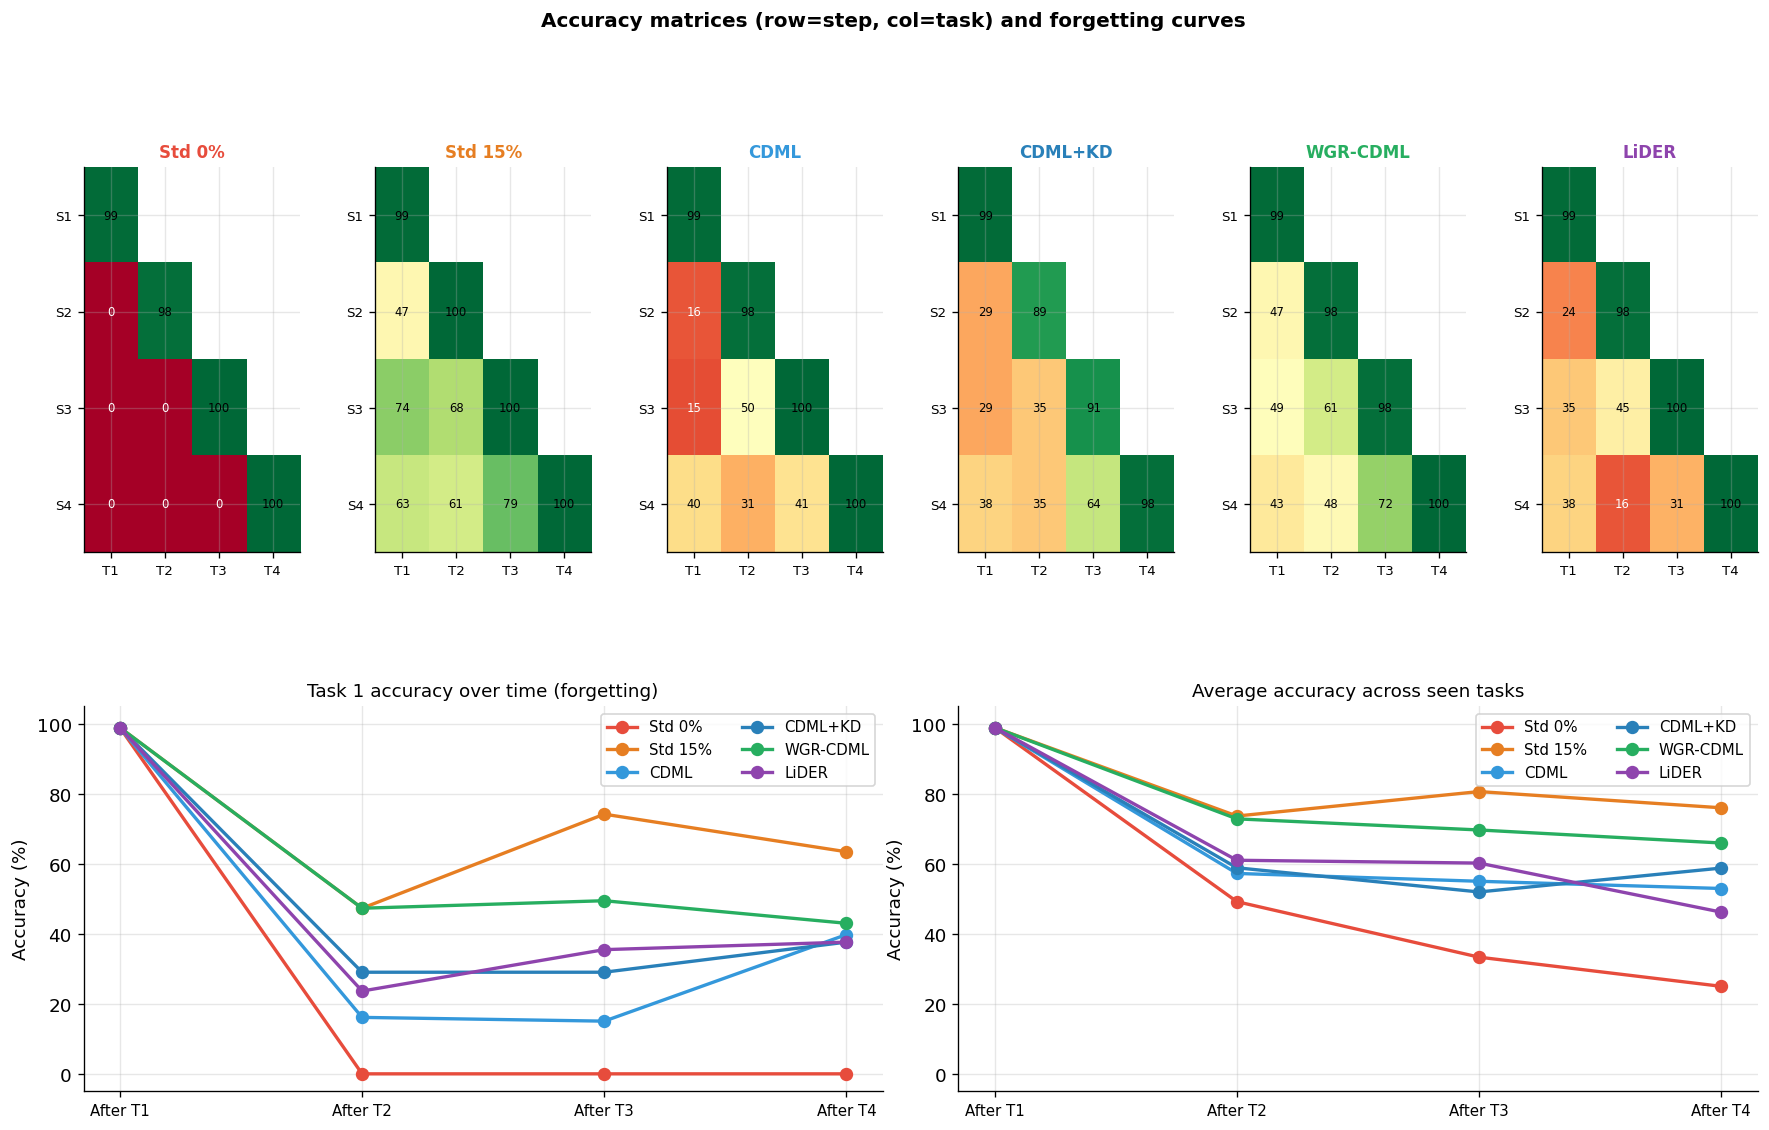

In [15]:
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=0.35)

# Row 0: accuracy matrices
for col, (label, _, mat, _, color) in enumerate(MODEL_REGISTRY):
    ax = fig.add_subplot(gs[0, col])
    masked = np.ma.masked_invalid(mat * 100)
    im = ax.imshow(masked, cmap='RdYlGn', vmin=0, vmax=100, aspect='auto')
    ax.set_xticks(range(n_tasks)); ax.set_yticks(range(n_tasks))
    ax.set_xticklabels([f'T{i+1}' for i in range(n_tasks)], fontsize=8)
    ax.set_yticklabels([f'S{i+1}' for i in range(n_tasks)], fontsize=8)
    ax.set_title(label, color=color, fontsize=10, fontweight='bold')
    for i in range(n_tasks):
        for j in range(n_tasks):
            if not np.isnan(mat[i,j]):
                v = mat[i,j]*100
                ax.text(j, i, f'{v:.0f}', ha='center', va='center',
                        fontsize=7, color='k' if v>20 else 'w')

# Row 1: Task 1 retention and average accuracy curves
ax_t1  = fig.add_subplot(gs[1, :3])
ax_avg = fig.add_subplot(gs[1, 3:])
steps  = list(range(1, n_tasks+1))

for label, _, mat, _, color in MODEL_REGISTRY:
    t1_vals  = [mat[s,0]*100 for s in range(n_tasks) if not np.isnan(mat[s,0])]
    avg_vals = [np.nanmean(mat[s,:s+1])*100 for s in range(n_tasks)]
    ax_t1.plot(steps[:len(t1_vals)], t1_vals, 'o-', color=color, lw=2, ms=7, label=label)
    ax_avg.plot(steps, avg_vals, 'o-', color=color, lw=2, ms=7, label=label)

for ax, title in [(ax_t1, 'Task 1 accuracy over time (forgetting)'),
                   (ax_avg, 'Average accuracy across seen tasks')]:
    ax.set_xticks(steps)
    ax.set_xticklabels([f'After T{s}' for s in steps], fontsize=9)
    ax.set_ylim(-5, 105); ax.set_ylabel('Accuracy (%)')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9, ncol=2)

fig.suptitle('Accuracy matrices (row=step, col=task) and forgetting curves',
             fontsize=12, fontweight='bold', y=1.01)
plt.savefig('fig_accuracy_overview.png', bbox_inches='tight')
plt.show()

---
## Attack A₂ — Membership Inference Attack (MIA)

**Goal:** Given a gait window (x, y), determine whether that specific sample was part of the model's training data.

**Protocol:** Threshold-based MIA (Yeom et al., 2018).  
Score function: `s(x, y) = −CE(f(x), y)` — lower loss → model memorised the sample → more likely to be a member.

**Members vs non-members:** Training windows vs test windows from the **same task and same subjects**.  
This is the hardest setting for the attacker (same distribution, only the window identity differs).

**CDML attacker modes:**
- **No-seed** (realistic): attacker zeros the modulation sequence — loss is inflated equally for all inputs, collapsing member/non-member separation.
- **Oracle** (upper bound): attacker knows the correct seed — the correct sequence is set before scoring.

**Metric:** AUC of the binary classifier induced by the score threshold. 50% = random guess (perfect privacy).


In [16]:
def run_mia(model, task_data, task_names, device, is_cdml=False,
            cdml_mode='none', n_samples=200):
    """
    Threshold-based MIA (Yeom et al. 2018).
    Members   = randomly sampled training windows for the task.
    Non-members = randomly sampled test windows from the same task
                  (same subjects, unseen windows — hardest setting).
    cdml_mode: 'none' | 'oracle' | 'no_seed'
    Returns: {task_name: {auc, eer, fpr, tpr, m_scores, nm_scores}}
    """
    results = {}
    for t_idx, task_name in enumerate(task_names):

        if cdml_mode == 'oracle' and is_cdml:
            model.set_task_sequence(task_name, CDML_SEED_BASE + t_idx)
        elif cdml_mode == 'no_seed' and is_cdml:
            model.set_task_sequence(task_name, 1)

        train_ds = task_data[task_name]['train']
        test_ds  = task_data[task_name]['test']

        rng     = np.random.default_rng(RANDOM_SEED + 77 + t_idx)
        n_mem   = min(n_samples, len(train_ds))
        n_non   = min(n_samples, len(test_ds))
        mem_idx = rng.choice(len(train_ds), n_mem, replace=False)
        non_idx = rng.choice(len(test_ds),  n_non, replace=False)

        model.eval()
        with torch.no_grad():
            X_mem = torch.stack([train_ds[int(i)][0] for i in mem_idx]).to(device)
            y_mem = torch.stack([train_ds[int(i)][1] for i in mem_idx]).to(device)
            losses_mem = nn.CrossEntropyLoss(reduction='none')(
                model(X_mem), y_mem).cpu().float().numpy()

            X_non = torch.stack([test_ds[int(i)][0] for i in non_idx]).to(device)
            y_non = torch.stack([test_ds[int(i)][1] for i in non_idx]).to(device)
            losses_non = nn.CrossEntropyLoss(reduction='none')(
                model(X_non), y_non).cpu().float().numpy()

        m_arr  = -losses_mem    # higher = lower loss = more likely member
        nm_arr = -losses_non

        scores = np.concatenate([m_arr, nm_arr])
        labels = np.concatenate([np.ones(len(m_arr)), np.zeros(len(nm_arr))])
        fpr, tpr, _ = roc_curve(labels, scores)
        roc_auc     = sk_auc(fpr, tpr)
        fnr         = 1 - tpr
        eer_idx     = np.nanargmin(np.abs(fpr - fnr))
        eer         = float(np.mean([fpr[eer_idx], fnr[eer_idx]]))

        results[task_name] = {
            'auc':       roc_auc,
            'eer':       eer,
            'fpr':       fpr,
            'tpr':       tpr,
            'm_scores':  m_arr,
            'nm_scores': nm_arr,
        }
    return results


print('Running MIA on all models...')
mia_results = {}

for label, model, _, is_cdml, _ in MODEL_REGISTRY:
    if not is_cdml:
        print(f'  {label}...')
        mia_results[label] = run_mia(model, task_data, task_names, DEVICE,
                                     is_cdml=False, cdml_mode='none')
    else:
        print(f'  {label} (no-seed)...')
        mia_results[f'{label} (no-seed)'] = run_mia(
            model, task_data, task_names, DEVICE, is_cdml=True, cdml_mode='no_seed')
        print(f'  {label} (oracle)...')
        mia_results[f'{label} (oracle)'] = run_mia(
            model, task_data, task_names, DEVICE, is_cdml=True, cdml_mode='oracle')

# Restore correct sequences after MIA
for label, model, _, is_cdml, _ in MODEL_REGISTRY:
    if is_cdml:
        model.set_task_sequence('Task 4', CDML_SEED_BASE + 3)

print('MIA complete.')


Running MIA on all models...
  Std 0%...
  Std 15%...
  CDML (no-seed)...
  CDML (oracle)...
  CDML+KD (no-seed)...
  CDML+KD (oracle)...
  WGR-CDML (no-seed)...
  WGR-CDML (oracle)...
  LiDER (no-seed)...
  LiDER (oracle)...
MIA complete.


── MIA Results: AUC per task (50% = random guess, threshold-based) ──
  Model                      |   Task 1 |   Task 2 |   Task 3 |   Task 4 | Avg
  ────────────────────────────────────────────────────────────────────────────────
  Std 0%                     |    52.5% |    52.2% |    52.5% |    56.6% |  53.5%
  Std 15%                    |    59.1% |    54.6% |    55.6% |    57.5% |  56.7%
  CDML (no-seed)             |    51.1% |    51.0% |    51.7% |    47.6% |  50.3%
  CDML (oracle)              |    50.4% |    50.4% |    48.9% |    60.4% |  52.5%
  CDML+KD (no-seed)          |    48.0% |    49.8% |    53.5% |    46.9% |  49.5%
  CDML+KD (oracle)           |    51.6% |    53.8% |    52.6% |    57.0% |  53.8%
  WGR-CDML (no-seed)         |    47.9% |    50.2% |    49.3% |    42.5% |  47.5%
  WGR-CDML (oracle)          |    53.0% |    51.4% |    55.6% |    62.4% |  55.6%
  LiDER (no-seed)            |    47.8% |    49.0% |    50.4% |    48.2% |  48.8%
  LiDER (oracle)             |

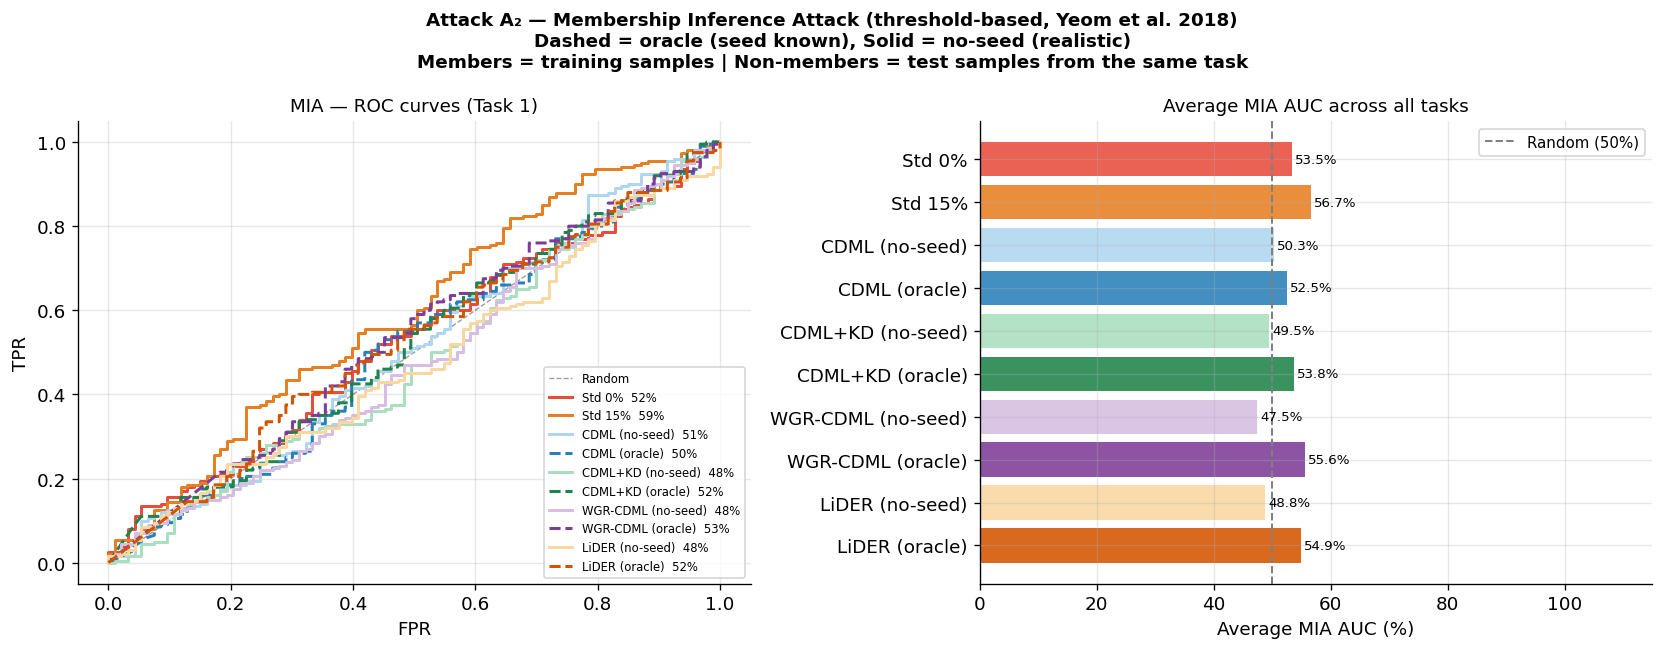

In [17]:
# ── MIA results table ─────────────────────────────────────────────────────────
print('── MIA Results: AUC per task (50% = random guess, threshold-based) ──')
header = f'  {"Model":<26} | ' + ' | '.join([f'{t:>8}' for t in task_names]) + ' | Avg'
print(header)
print('  ' + '─' * 80)
for key, res in mia_results.items():
    aucs = [res[t]['auc'] * 100 for t in task_names]
    print(f'  {key:<26} | ' + ' | '.join([f'{a:>7.1f}%' for a in aucs])
          + f' | {np.mean(aucs):>5.1f}%')

# EER table
print()
print('── MIA Results: EER per task (50% = random guess) ──')
print(header.replace('AUC', 'EER'))
print('  ' + '─' * 80)
for key, res in mia_results.items():
    eers = [res[t]['eer'] * 100 for t in task_names]
    print(f'  {key:<26} | ' + ' | '.join([f'{e:>7.1f}%' for e in eers])
          + f' | {np.mean(eers):>5.1f}%')

# ── MIA colour scheme (mirrors IIA) ──────────────────────────────────────────
mia_colors = {
    'Std 0%':             '#E74C3C', 'Std 15%':              '#E67E22',
    'CDML (no-seed)':     '#AED6F1', 'CDML (oracle)':        '#2980B9',
    'CDML+KD (no-seed)':  '#A9DFBF', 'CDML+KD (oracle)':     '#1E8449',
    'WGR-CDML (no-seed)': '#D7BDE2', 'WGR-CDML (oracle)':    '#7D3C98',
    'LiDER (no-seed)':    '#FAD7A0', 'LiDER (oracle)':       '#D35400',
}

FOCUS_TASK_MIA = 'Task 1'

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ── ROC curves (Task 1) ───────────────────────────────────────────────────────
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.4, label='Random')
for key, res in mia_results.items():
    if key not in mia_colors:
        continue
    fpr, tpr = res[FOCUS_TASK_MIA]['fpr'], res[FOCUS_TASK_MIA]['tpr']
    roc_a    = res[FOCUS_TASK_MIA]['auc']
    ls = '--' if 'oracle' in key else '-'
    ax.plot(fpr, tpr, color=mia_colors[key], lw=1.8, ls=ls,
            label=f'{key}  {roc_a * 100:.0f}%')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title(f'MIA — ROC curves ({FOCUS_TASK_MIA})', fontsize=11)
ax.legend(fontsize=7, loc='lower right', ncol=1)

# ── Average AUC bar chart ─────────────────────────────────────────────────────
ax2 = axes[1]
mia_keys   = list(mia_results.keys())
mia_avgs   = [np.mean([mia_results[k][t]['auc'] * 100 for t in task_names])
              for k in mia_keys]
bar_colors = [mia_colors.get(k, '#888') for k in mia_keys]
bars = ax2.barh(mia_keys[::-1], mia_avgs[::-1], color=bar_colors[::-1], alpha=0.88)
ax2.axvline(50, color='gray', ls='--', lw=1.2, label='Random (50%)')
for bar in bars:
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
             f'{bar.get_width():.1f}%', va='center', fontsize=8)
ax2.set_xlabel('Average MIA AUC (%)')
ax2.set_title('Average MIA AUC across all tasks', fontsize=11)
ax2.set_xlim(0, 115)
ax2.legend(fontsize=9)

plt.suptitle(
    'Attack A\u2082 \u2014 Membership Inference Attack (threshold-based, Yeom et al. 2018)\n'
    'Dashed = oracle (seed known), Solid = no-seed (realistic)\n'
    'Members = training samples | Non-members = test samples from the same task',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_mia_results.png', bbox_inches='tight')
plt.show()
